In [221]:
import torch 
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from helper_function import plot_decision_boundary

In [222]:
def accuracy_fn(y_true: torch.Tensor, y_pred: torch.Tensor) -> float:
    """Calculates accuracy for multi-class classification."""
    correct = (y_true == y_pred).sum().item()
    total = len(y_true)
    return (correct / total) * 100  # returns accuracy in %

In [223]:
X, y = make_blobs(n_samples = 1000, cluster_std = 1.5, centers = 4, random_state = 42)
X[:5]

array([[-8.41339595,  6.93516545],
       [-5.76648413, -6.43117072],
       [-6.04213682, -6.76610151],
       [ 3.95083749,  0.69840313],
       [ 4.25049181, -0.28154475]])

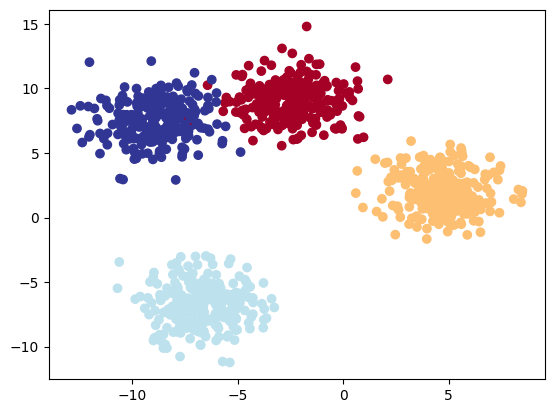

In [224]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [225]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [226]:
X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.LongTensor)

In [227]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [228]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [229]:
X_train.shape, y_train.unique()

(torch.Size([800, 2]), tensor([0, 1, 2, 3], device='mps:0'))

In [230]:
class BlobsModel(nn.Module):
    def __init__(self, in_features: int = 0, out_features: int = 0, hidden_units: int = 8):
        super().__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        
        self.layer = nn.Sequential(
            nn.Linear(self.in_features, self.hidden_units),
            nn.ReLU(),
            nn.Linear(self.hidden_units, self.hidden_units),
            nn.ReLU(),
            nn.Linear(self.hidden_units, self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer(x)

In [231]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [232]:
model = BlobsModel(in_features = 2, out_features = 4, hidden_units = 32).to(device)
model

BlobsModel(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)

In [233]:
y_logits = torch.softmax(model(X_train), dim = 1, dtype = torch.float)
y_logits[0].argmax()

tensor(2, device='mps:0')

In [234]:
model.eval()
with torch.inference_mode():
    y_logits = torch.softmax(model(X_train), dim = 1, dtype = torch.float)
    y_pred = torch.argmax(y_logits, dim = 1)

y_pred[: 10], y_test[: 10]

(tensor([2, 1, 3, 1, 1, 2, 1, 2, 1, 1], device='mps:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0'))

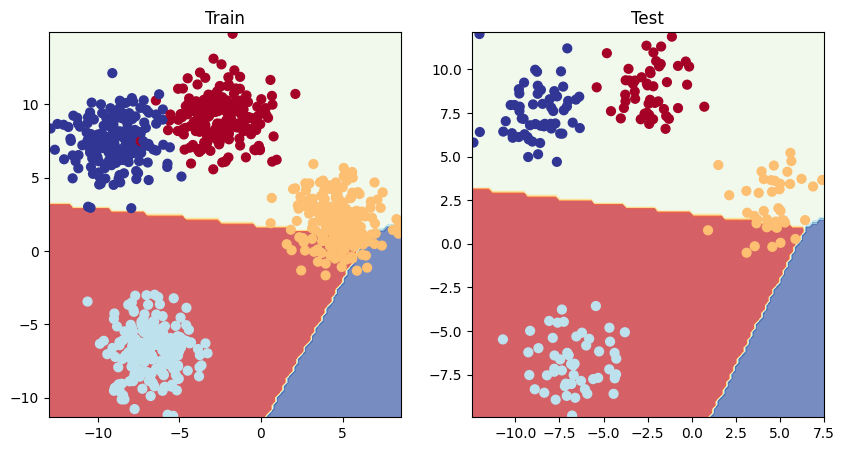

In [47]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

In [235]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.1)

In [236]:
epochs = 1000
total_epochs = []
losses = []
test_losses = []

for epoch in range(epochs):
    model.train()

    y_logits = model(X_train)
    y_pred = torch.argmax(y_logits, dim = 1)
    train_accuracy = accuracy_fn(y_train, y_pred)

    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_test_logits = model(X_test)
        y_test_pred = torch.argmax(y_test_logits, dim = 1)
        test_accuracy = accuracy_fn(y_test, y_test_pred)

        test_loss = loss_fn(y_test_logits, y_test)
        test_losses.append(test_loss.item())

    total_epochs.append(epoch)
    if epoch % (0.1 * epochs) == 0:
        print(f"Train Loss: {loss} | Test Loss: {test_loss}")
        print(f"Train Accuracy: {train_accuracy} | Test Accuracy: {test_accuracy}\n")

Train Loss: 1.7375990152359009 | Test Loss: 0.7256681323051453
Train Accuracy: 1.5 | Test Accuracy: 59.5

Train Loss: 0.015185307711362839 | Test Loss: 0.003188233356922865
Train Accuracy: 99.375 | Test Accuracy: 100.0

Train Loss: 0.014237803407013416 | Test Loss: 0.002779075875878334
Train Accuracy: 99.375 | Test Accuracy: 100.0

Train Loss: 0.013489664532244205 | Test Loss: 0.002528371522203088
Train Accuracy: 99.375 | Test Accuracy: 100.0

Train Loss: 0.013968121260404587 | Test Loss: 0.003586397971957922
Train Accuracy: 99.625 | Test Accuracy: 100.0

Train Loss: 0.012975921854376793 | Test Loss: 0.0042236559092998505
Train Accuracy: 99.625 | Test Accuracy: 100.0

Train Loss: 0.010777277871966362 | Test Loss: 0.0020299300085753202
Train Accuracy: 99.625 | Test Accuracy: 100.0

Train Loss: 0.011635580100119114 | Test Loss: 0.0020862948149442673
Train Accuracy: 99.75 | Test Accuracy: 100.0

Train Loss: 0.011871418915688992 | Test Loss: 0.0024320511147379875
Train Accuracy: 99.5 | Tes

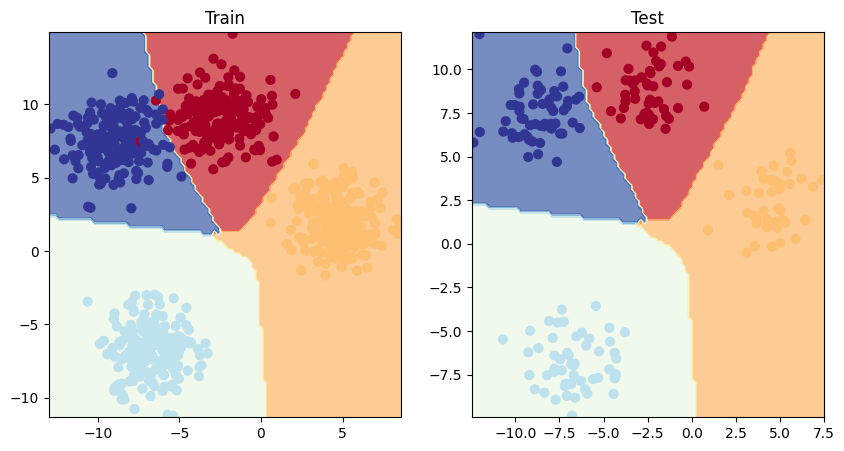

In [218]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

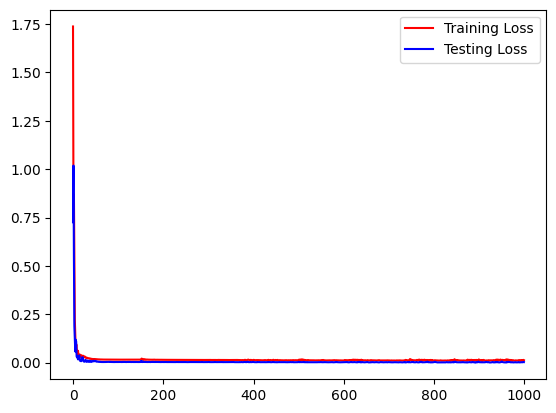

In [237]:
plt.plot(total_epochs, losses, label = "Training Loss", c = "red")
plt.plot(total_epochs, test_losses, label = "Testing Loss", c = "blue")
plt.legend()
plt.show()

In [238]:
model.eval()
with torch.inference_mode():
    y_logits = model(X_test)
    y_pred = torch.argmax(y_logits, dim = 1)

y_pred[:10], y_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0'),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0'))